# AIS Ship Trajectory Analysis with GeoPandas
This notebook queries AIS vessel positions from a SQLite database and visualizes ship trajectories on interactive maps using GeoPandas.

## 1. Import Required Libraries

In [7]:
import sys
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
import geodatasets
import warnings

# Add actint to path for imports
actint_path = Path("/home/daxtonb/JFN-Groundtruth-Tools/actint/src")
if str(actint_path) not in sys.path:
    sys.path.insert(0, str(actint_path))

from actint.data_processing.query_database import query_ais_positions, query_vessels

warnings.filterwarnings('ignore')

## 2. Connect to Database and Query Ship Positions

In [8]:
# Query positions for a specific ship (configure as needed)
# For example: query_ais_positions({"MMSI": "123456789"}) or {"vessel_id": value}

SHIP_QUERY = {"MMSI": 338839000}  # Change MMSI or column name as needed

try:
    ship_positions = query_ais_positions(SHIP_QUERY, sort=True)
    print(f"Retrieved {len(ship_positions)} positions")
    if ship_positions:
        print(f"Sample position: {ship_positions[0]}")
except Exception as e:
    print(f"Error querying database: {e}")
    ship_positions = []

2023-01-01T00:00:03.000000
Retrieved 1243 positions
Sample position: (10685, 338839000, '2023-01-01T23:59:03.000000', 32.67562, -117.12242, 0.0, 101.7, 511.0, 'USS FITZGERALD', None, 'NFTZ', 90.0, 0.0, 139.0, 20.0, None, 0.0, 'A', '2026-02-26 03:51:09')


## 3. Convert Query Results to GeoDataFrame

In [9]:
def convert_to_geodataframe(query_results, lat_idx=3, lon_idx=4, timestamp_idx=2):
    """
    Convert query results to a GeoDataFrame.
    
    Parameters:
    - query_results: list of tuples from query_ais_positions
    - lat_idx: column index for latitude (default: 3)
    - lon_idx: column index for longitude (default: 4)
    - timestamp_idx: column index for timestamp (default: 2)
    
    Returns:
    - GeoDataFrame with geometry points
    """
    if not query_results:
        print("No query results to convert")
        return None
    
    # Convert tuples to list of dictionaries
    data = []
    for row in query_results:
        try:
            data.append({
                'latitude': float(row[lat_idx]),
                'longitude': float(row[lon_idx]),
                'timestamp': row[timestamp_idx],
                'raw_data': row
            })
        except (IndexError, ValueError, TypeError) as e:
            print(f"Skipping row due to error: {e}")
            continue
    
    if not data:
        print("No valid data points found")
        return None
        
    df = pd.DataFrame(data)
    
    # Create geometry column from coordinates
    geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    
    print(f"Created GeoDataFrame with {len(gdf)} points")
    return gdf

# Convert the query results
if ship_positions:
    gdf = convert_to_geodataframe(ship_positions)
    if gdf is not None:
        print(gdf.head())
else:
    gdf = None
    print("No ship positions to convert")

Created GeoDataFrame with 1243 points
   latitude  longitude                   timestamp  \
0  32.67562 -117.12242  2023-01-01T23:59:03.000000   
1  32.67554 -117.12249  2023-01-01T23:57:52.000000   
2  32.67554 -117.12247  2023-01-01T23:56:43.000000   
3  32.67563 -117.12246  2023-01-01T23:55:42.000000   
4  32.67561 -117.12236  2023-01-01T23:54:33.000000   

                                            raw_data  \
0  (10685, 338839000, 2023-01-01T23:59:03.000000,...   
1  (10677, 338839000, 2023-01-01T23:57:52.000000,...   
2  (10668, 338839000, 2023-01-01T23:56:43.000000,...   
3  (10661, 338839000, 2023-01-01T23:55:42.000000,...   
4  (10655, 338839000, 2023-01-01T23:54:33.000000,...   

                      geometry  
0  POINT (-117.12242 32.67562)  
1  POINT (-117.12249 32.67554)  
2  POINT (-117.12247 32.67554)  
3  POINT (-117.12246 32.67563)  
4  POINT (-117.12236 32.67561)  


## 4. Visualize Ship Positions on Map

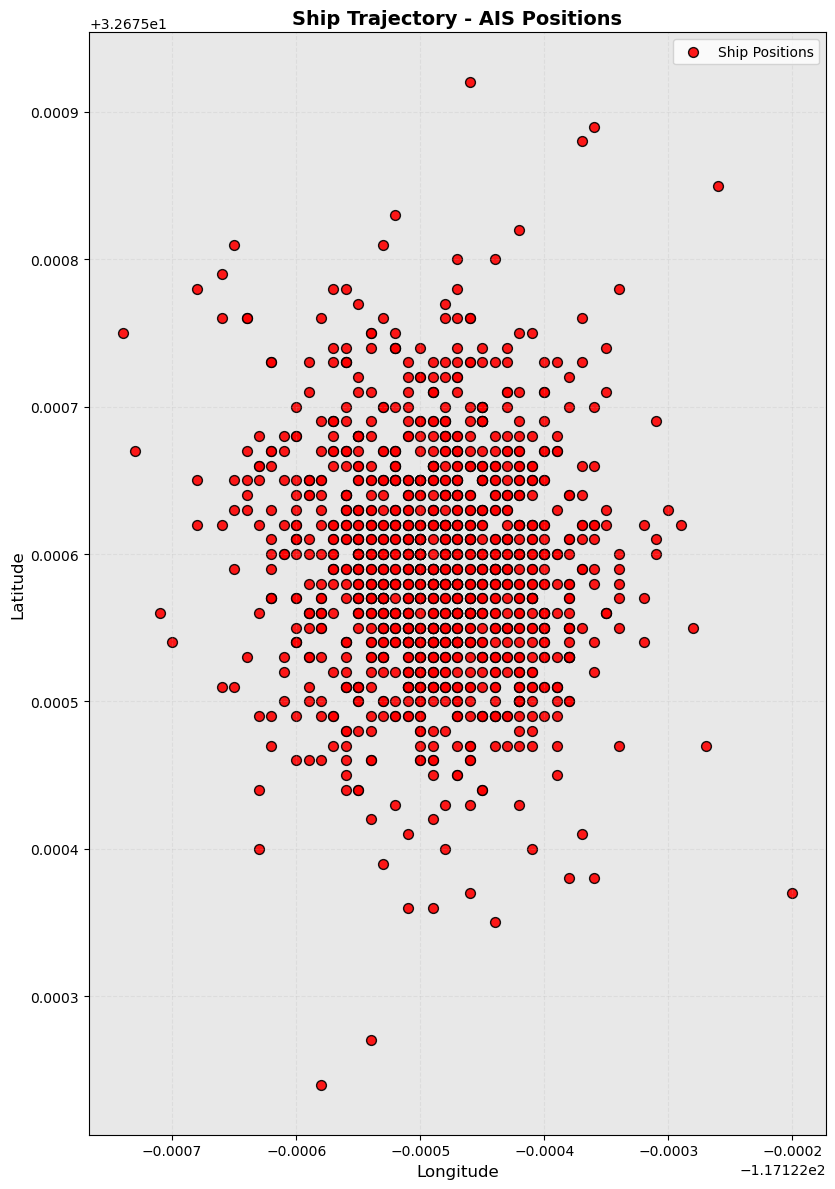

Map displayed with 1243 vessel positions
Latitude range: 32.6752 to 32.6759
Longitude range: -117.1227 to -117.1222


In [10]:
if gdf is not None and len(gdf) > 0:
    
    # Create a figure with matplotlib
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Load and plot world map as background
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
    world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
    
    # Plot the ship positions on top
    gdf.plot(ax=ax, alpha=0.9, edgecolor='k', markersize=50, color='red', label='Ship Positions')
    
    # Zoom to the area covered by the data with a small margin
    xmin, ymin, xmax, ymax = gdf.total_bounds
    xmargin = (xmax - xmin) * 0.05
    ymargin = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - xmargin, xmax + xmargin)
    ax.set_ylim(ymin - ymargin, ymax + ymargin)
    
    # Add grid
    ax.grid(True, alpha=0.2, linestyle='--')
    
    # Add labels
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'Ship Trajectory - AIS Positions', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Map displayed with {len(gdf)} vessel positions")
    print(f"Latitude range: {gdf['latitude'].min():.4f} to {gdf['latitude'].max():.4f}")
    print(f"Longitude range: {gdf['longitude'].min():.4f} to {gdf['longitude'].max():.4f}")
else:
    print("No GeoDataFrame to plot")

## 5. Filter and Analyze Multiple Ship Trajectories

In [11]:
def plot_multiple_ships(ship_queries, lat_idx=3, lon_idx=4, timestamp_idx=2):
    """
    Query and plot multiple ship trajectories on the same map.
    
    Parameters:
    - ship_queries: list of dictionaries with query parameters
    - lat_idx, lon_idx, timestamp_idx: column indices
    """
    fig, ax = plt.subplots(figsize=(18, 14))
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    # Load and plot world map as background
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
    world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
    
    for i, query in enumerate(ship_queries):
        try:
            positions = query_ais_positions(query, sort=True)
            gdf_ship = convert_to_geodataframe(positions, lat_idx, lon_idx, timestamp_idx)
            
            if gdf_ship is not None and len(gdf_ship) > 0:
                color = colors[i % len(colors)]
                gdf_ship.plot(ax=ax, alpha=0.7, color=color, markersize=30, label=f"Ship {i+1}")
                print(f"Plotted {len(gdf_ship)} positions for query: {query}")
        except Exception as e:
            print(f"Error plotting ship {i+1}: {e}")
    
    # Add grid
    ax.grid(True, alpha=0.2, linestyle='--')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Multiple Ship Trajectories - AIS Positions', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

# Example: Plot multiple ships
# Uncomment and modify the queries below to compare multiple vessels
SHIP_QUERIES = [
    {"MMSI": "123456789"},
    # {"MMSI": "987654321"},
    # Add more queries as needed
]

if len(SHIP_QUERIES) > 1:
    plot_multiple_ships(SHIP_QUERIES)
else:
    print("Add multiple ship queries to plot_multiple_ships(SHIP_QUERIES) to compare trajectories")

Add multiple ship queries to plot_multiple_ships(SHIP_QUERIES) to compare trajectories
